# Neoclassical Firm Dynamics
Questions? Contact T.F. Martin Aragoneses | maragoneses@g.harvard.edu

Since you already worked out your own code to solve the Huggett model, this time I will hold your hands a little less through the code, highlighting the key ingredients for you to build on. 

*Topics for Today* 

1. Investment adjustment costs
2. Entry and exit forward and backward iteration
3. Calibration with muti-dimensional targets/moment conditions
4. Re-calibration vs. cross steady state dynamics
5. Stochastic simulation
6. BONUS: Derivations for the wage Phillips Curve in the One Asset HANK model

In Hugget, the goal was to micro-found *asset* demand by households in a world where assets were in zero net supply (or, equivalently, the savings supply (and consumption demand) function where there was no vehicle to put their savings on beyond trading with one another). Aggregating households actions delivered $\mathcal{A}(r)$. Our key equilibrium condition was asset market clearing $\mathcal{A}(r) = 0$. 

Today, we will cover a model that micro-founds *labor* demand by firms, when labor is supplied by households. Firm models tend to be more complex than household models. Aggregating firms' actions will deliver $\mathcal{N}(w)$. 


## Basic Firm Dynamics Model

In Hugget, the goal was to micro-found *asset* demand by households in a world where assets were in zero net supply (or, equivalently, the savings supply (and consumption demand) function where there was no vehicle to put their savings on beyond trading with one another). Aggregating households actions delivered $\mathcal{A}_t(r)$. Our key equilibrium condition was asset market clearing $\mathcal{A}(r) = 0$. Today, we are going to simplify our lives and assume a representative household with problem:

$$ \max\,\sum_{t=0}^{\infty}\beta^{t}\log C_{t} $$ $$ C_{t}+A_{t}\leq(1+r_{t-1})A_{t-1}+w_{t}N $$

You should be able to show that in the steady state $r$ is defined by $(1+r)\beta = 1$ for aggregate consumption to be constant.

Today, we will cover a model that micro-founds *labor* demand by firms, when labor is supplied by households. Firm models tend to be more complex than household models. Aggregating firms' actions will deliver an aggregate labor demand function $\mathcal{N}_t(w)$ as well as a stream of aggregate dividends or profits $\Phi_t(w)$. Unlike the previous model, where the only vehicle for household savings were $0$ net supply bonds priced at $r$ since there was no government or firms' capital to provide liquidity, in today's model the presence of firms with outstanding profits will allow for households to invest their wealth in the aggregate stock market. 

Let $A_{t}^{f}$ be the **total value of firms** in the economy, defined by a perfect foresight no arbitrage condition making the household indifferent between holding bonds or an index of all stocks of companies in the economy. 

$$ 1+r_{t} =\frac{\left[\Phi_{t+1}+A_{t+1}^{f}\right]}{A_{t}^{f}} $$ 

How are these dividends defined? We need to describe the firm's problem. 

### Problem with a mass 1 of firms 

Firms do not have capital, but treat labor as an investment 

$$ \max\,V_{t}(s,n_{-})=\max_{n}\,\left\{ d+\frac{1}{1+r_{t}}\mathbb{E}\left[V_{t+1}(s',n)\big\vert s\right]\right\}  $$ 

Initially, we assume firms neither die nor enter, they simply exist and hire labor to make flow profits

$$ d=f(s,n_{-})-w_{t}n_{-}-\Psi\left(n,n_{-}\right), \quad f(s,n_{-})=X_{t}s^{\alpha}n_{-}^{1-\alpha} $$

The key ingredient is the fact that we introduce *convex* adjustment costs to labor in terms of *growth rates*.

$$ \Psi\left(n,n_{-}\right)=\frac{\psi}{2}\left(\frac{n}{n_{-}}-1\right)^{2}n_{-} $$ 

When you solve this model, you might want to see how the shape of equilibrium policies and distribution changes once you introduce *absolute* adjustment costs $ \Psi\left(n,n_{-}\right)=\frac{\psi}{2}\left(n - n_{-}\right)^{2} $ or *non-convex* adjustment costs $\Psi\left(n,n_{-}\right)=\psi \max ( n_{-} - n, 0)$. 

Adjustment costs affect that shape of the labor demand we get when aggregating across firms $\mathcal{N}_t(w)$

$$ N_{t}^{f}=\int n_{-}dD_{t}(s,n_{-}) $$

As well as aggregate output

$$ Y_{t}=\int f(s,n_{-})dD_{t}(s,n_{-}) $$

Aggregate dividends in turn

$$\Phi_{t}=\int d(s,n_{-})dD_{t}(s,n_{-})=Y_{t}-w_{t}N_{t}^{f}-\Psi_{t}$$

In general equilibrium, (1) the household optimizes, (2) firms optimize, and (3) markets clear:

$$ A_{t}=A_{t}^{f} $$ 
$$ N=N_{t}^{f}$$ 
$$ C_{t}=Y_{t}-\Psi_{t}$$ 

Note that since we are focusing on a stationary equilibrium only

$$ A_{t}^{f}=\frac{1}{1+r_{t}}\left[\Phi_{t+1}+A_{t+1}^{f}\right] = A^f  = \frac{\Phi}{r} ,\quad r = (1/\beta) - 1 $$

Recall that also in the steady state, in equilibrium

$$ C = r A + w N  = Y - \Psi $$ 



In [227]:
import sys  
sys.path.insert(0, '/Volumes/GoogleDrive/My Drive/SHADE')
# custom tools: vectorized interpolation, optimization, discretization, and differentitation 
import utilities  # we'll be using these throughout the course! 
# check out setmin, interpolate_y, interpolate_coord_robust, 

# standard tools in Python for economists: you'll learn about these in quant econ! 
import numpy as np 
from   numpy import linspace, logspace, log, exp
import scipy.optimize as opt
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import interp1d
from numba import jit, njit, guvectorize  # vectorizes loops to improve performance
from numpy.matlib import repmat
import quantecon as qe

**Calibration** 

$\beta=0.8. \alpha=0.66. Y=1. \psi= 4. \log s$ follows an AR(1) with persistence $\rho$ and standard deviation of the shocks of 0.2. Discretize it using Rouwenhorst methods over at least 7 points. Make sure to define $n_{-}$ on a grid of at least 100 points.

In [231]:
# Parametrization and steady state quarterly calibration with guessed parameters

# set model parameters

# define functions - useful to write one line functions like f @(x) ... in MATLAB

# e.g. f(s,n_)

# set numerical parameters

 Choose the min and max points on the $n_{-}$ grid judiciously.

Dispersion parameter: σ =  0.2


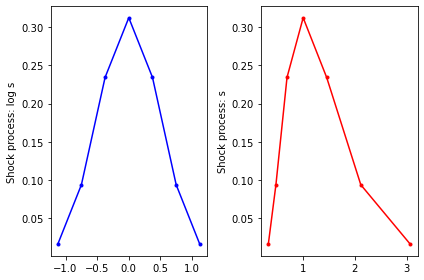

Sum P given col over rows =  [0.78 1.06 1.11 1.11 1.11 1.06 0.78]
Sum P given row over cols =  [1. 1. 1. 1. 1. 1. 1.]


array([[0.32500882, 0.47271214, 0.68754065, 1.        , 1.45445946,
        2.11545231, 3.07683962]])

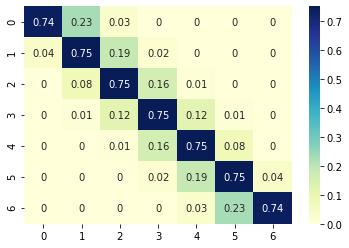

In [232]:
# Let's explore what's in the discretized markov chain from Quant Econ
mc  = qe.markov.approximation.rouwenhorst(ns, μ, σ, ρ)

# mc is a dictionary: look at print(mc.__dict__)

# Get a stationary distribution from the qe.markov.core.MarkovChain class defined over P 
s_grid = exp(np.asarray(mc._state_values)) # spits out tuple, we want array; we don't want it in logs
s_grid.shape = (ns,1) # turn into an proper vector

# get stationary dist and Π transition



We need to create a grid so that for any of the two inputs on the firm's problem $Y,w$, and for any choice the firm makes, we can compute their production and current dividends. First, production

$$ y = Z_{t}s^{\alpha}n_{-}^{1-\alpha} $$ 

This functional form is nice because it delivers linearity of $n(s)$ if labor was chosen statically.

$$ n^{\psi = 0}\left(s;Z,w\right)=\left(\left(1-\alpha\right)\frac{Z_{t}}{w_{t}}\right)^{\frac{1}{\alpha}}s,$$ 

In our dynamic choice will likely be non-linear, and any non-linearity will be due to the adjustment costs, but it will have the same GE inputs, and in addition, $r$, because labor is chosen as an investment. 

Since in equilibrium adjustment costs will likely tend to lower labor demand, assuming an inelastic $L=1$, we will have that wages cannot be above what they would be under no adjustment costs, namely

$$ \left(\left(1-\alpha\right)\frac{Z_{t}}{w_{t}}\right)^{\frac{1}{\alpha}}\int sD\left(s\right) = \bar{L} $$ 

$$ w_{t}=\left(1-\alpha\right)Z_{t}\left(\frac{L}{\bar{s}}\right)^{-\alpha} \implies n=\frac{s}{\bar{s}}L$$ 

Hence, choosing $n_\max$ to be higher than such value would be judicious. However, since we are not allowing for endogenous exit, a good practice is to make sure that for whatever $n_\max$ you choose no firm will want to exit. 

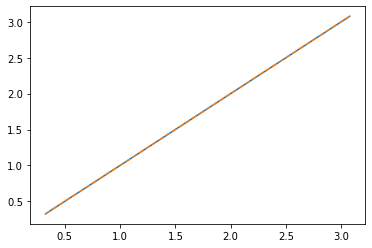

In [233]:
nstatic = (s_grid/exp(μ))*L
plt.plot(s_grid,nstatic)
plt.plot(s_grid,s_grid,'--')

In the model with labor, having a larger labor force is a drag with absolute adjustment costs, but not really with relative adjustment costs. Hence, we have chosen to use relative adjustment costs.


nmax [4.61525944]
Two a grids steps


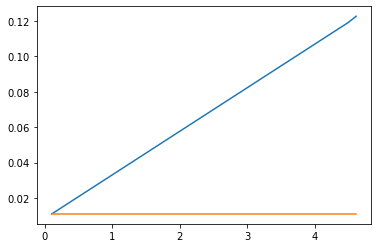

ms_grid.shape =  (7, 100)
[[0.325 0.325 0.325 0.325 0.325 0.325]
 [0.473 0.473 0.473 0.473 0.473 0.473]
 [0.688 0.688 0.688 0.688 0.688 0.688]
 [1.    1.    1.    1.    1.    1.   ]
 [1.454 1.454 1.454 1.454 1.454 1.454]]

mn_grid.shape =  (7, 100)
[[0.1   0.111 0.122 0.134 0.146 0.158]
 [0.1   0.111 0.122 0.134 0.146 0.158]
 [0.1   0.111 0.122 0.134 0.146 0.158]
 [0.1   0.111 0.122 0.134 0.146 0.158]
 [0.1   0.111 0.122 0.134 0.146 0.158]]
Profits without adjustment costs


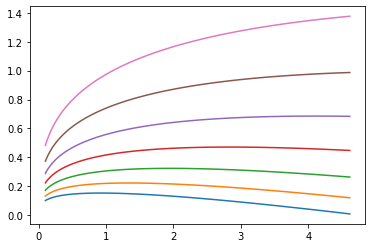

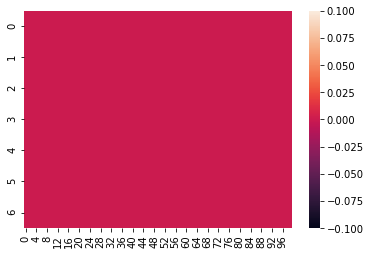

In [234]:
# set up nmax nmin and n_grid 

# ... 


# profits:

mpi  = y(ms_grid,mn_grid,Z) - w*mn_grid
md_min  = y(ms_grid,mn_grid,Z) - w*mn_grid

# Create an initial guess for the distribution repmatting the Markov distribution : x na


# store parameters

param = {'ns': ns, 'y': y, 'fn': fn, 'psi': psi, 'psi1': psi1, 'psi2': psi2, 'ρ': ρ, 'σ': σ, 'μ': μ, 'β': β, 'Y': Y, 'L': L, 'r': r, 'w': r, 'Z': Z, 'backward_tol': backward_tol, 'backward_maxit': backward_maxit, 'forward_tol': forward_tol , 'forward_maxit': forward_maxit, 'shooting_tol': shooting_tol, 'shooting_maxit': shooting_maxit}


param['Π'], param['δ'], param['κe'], param['nmin'] , param['nmax'] , param['nn'], param['n_grid'] , param['s_grid'],  param['mn_grid'] , param['ms_grid']=  Π, δ, κe, nmin, nmax, nn, n_grid, s_grid, mn_grid, ms_grid
param['Dguess'] = Dguess

Note unlike in the household problem, firms are allowed to run negative dividends (i.e. raise equity at no cost) in a period as long as their value does not fall below 0. This is unlike the household problem, where standard utility functions prevent us from consuming 0, and firm models with equity issuance constraints (which impose $d \ge 0$).

Here, you are going to learn how to apply the interpolation-based EGM algorithm to solve the firm's problem using as inputs three aggregates $(w_t,Z_t,r_t)$

The firm problem has the following **FOC** 

$$ \Psi_{1,t}\left(n,n_{-}\right)=\frac{1}{1+r_{t}}\Pi V_{n,t+1}\left(s^{\prime},n\right)=\frac{1}{1+r_{t}}W_{n,t+1}\left(s,n\right) $$

and an **envelope condition** 

$$ V_{n,t}\left(s,n_{-}\right)=\left[f_{n}\left(s,n_{-};Z_t\right)-w_{t}\right]-\Psi_{2,t}\left(n,n_{-}\right)$$ 

Follow the endogenous grid point method to solve the problem 

1. Guess $V_{n,t+1}\left(s^{\prime},n\right)$ over next period's TFP and labor choice.
2. Take expected value to transform this in terms of current $s$ 
$$ W_{n,t+1}\left(s,n\right)  = \Pi V_{n,t+1}\left(s^{\prime},n\right)$$
3. Find the endogenous grid point today for any $s$ and tomorrow's grid point $n$.
$$ n_{-}\left(s,n\right)=\Psi_{1,t}^{-1}\left(n,\frac{1}{1+r_{t}}W_{n,t+1}\left(s,n\right)\right)$$
4. Problem? Such $n_{-}\left(s,n\right)$ will not be in our original grid for $n_{-}$ so we need to translate it via interpolation. For any $s$ given, we have that 

$$ \Psi_{1,t}^{-1}\left(n,\frac{1}{1+r_{t}}W_{n,t+1}\left(s,n\right)\right) = LHS(n) = RHS(n_{-}) =  n_{-}$$

5. After finding $n(s,n_{-})$ interpolated on the desired grid, we can use it to compute a new value for $V_{n,t}\left(s,n_{-}\right)$

$$ V_{n,t}\left(s,n_{-}\right)=\left[f_{n}\left(s,n_{-};Z_t\right)-w_{t}\right]-\Psi_{2,t}\left(n(s,n_{-}),n_{-}\right)$$ 

6. Iterate until the terminal condition

What's a good initial guess for our function? Applying the Envelope Condition assuming that $n = n_{-}$, which  will deliver static marginal profits. 

$$ V^0_{n,t}\left(s,n_{-}\right)=\left[f_{n}\left(s,n_{-};Z_t\right)-w_{t}\right]$$ 


**Important** Do not miss the - w here, otherwise firms are always going to want to grow!! 

As a note, you are computing marginal value functions here since you are solving the problem essentially exploiting the optimality conditions. To find $\int V(s,n_{-})dD(s,n_{-})$ simply carry it's value inside the backward iteration adding $V = d + \frac{1}{(1+r)} \Pi V'$ after you compute optimal dividends in each period.


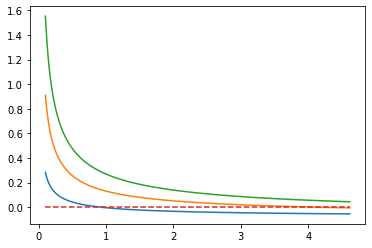

In [237]:
# Guess marginal

Vn0 = ...

plt.plot(n_grid,Vn0[0,:])
plt.plot(n_grid,Vn0[round(ns/2),:])
plt.plot(n_grid,Vn0[-1,:])
plt.plot(n_grid,np.zeros_like(n_grid),'--')
plt.show()

Vn_p = Vn0

In [9]:
def firm(Vn_p,V_p,param,w,r,Z):
    # unpack param
    
    Psi1    = # x = Psi1(s,n)
    
    n_endog =  # Invert to get n_ 
    
    # interpolate
    
    # get matrices including Vn and V!
    
    return Vn, V, n, d, yy, Psi

def backward_ss(param,w,r,Z):
    # guess 
    
    # loop
    
    return firm(Vn_p,V0,param,w,r,Z)

def forward(D, Π_T, x_i, x_pi):

# Create function D = forward_ss(param,r,Y)
def forward_ss(param,x_i,x_pi):
    

In [10]:
Vn, V0, n, d, yy, Psi    = backward_ss(param,w,r,Z)      # iterate until Vn converges
x_i, x_pi = utilities.interpolate_coord_robust(n_grid, n) # find where a lays on a_grid
D = forward_ss(param,x_i,x_pi)

assert np.sum(np.sum(((x_pi < np.zeros_like(x_pi)) | (x_pi >  np.ones_like(x_pi) )))) == 0
n_interpol = np.take(mn_grid, x_i) # index ma_grid values according to x_i index
print("a grid")
print(np.round(n_grid[0:5],3)) # previous value
print("Policy off grid")
print(np.round(n[0:7,0:5],3)) # previous value
print("Policy on grid")
print(np.round(n_interpol[0:7,0:5],3)) # current savings
print("Prev value")
print(np.round(n_grid[0:5],3)) # previous value
print("Index")
print(x_i[0:7,0:5])
print("Weight")
print(np.round(x_pi[0:7,0:5],3)) # if you start here, you stay here.

a grid
[0.1   0.111 0.122 0.134 0.146]
Policy off grid
[[0.135 0.146 0.158 0.17  0.183]
 [0.141 0.153 0.165 0.178 0.19 ]
 [0.148 0.16  0.173 0.186 0.199]
 [0.156 0.169 0.182 0.195 0.209]
 [0.166 0.179 0.192 0.206 0.22 ]
 [0.176 0.19  0.204 0.218 0.233]
 [0.189 0.203 0.218 0.233 0.248]]
Policy on grid
[[0.134 0.146 0.158 0.158 0.17 ]
 [0.134 0.146 0.158 0.17  0.183]
 [0.146 0.158 0.17  0.183 0.196]
 [0.146 0.158 0.17  0.183 0.196]
 [0.158 0.17  0.183 0.196 0.21 ]
 [0.17  0.183 0.196 0.21  0.224]
 [0.183 0.196 0.21  0.224 0.238]]
Prev value
[0.1   0.111 0.122 0.134 0.146]
Index
[[ 3  4  5  5  6]
 [ 3  4  5  6  7]
 [ 4  5  6  7  8]
 [ 4  5  6  7  8]
 [ 5  6  7  8  9]
 [ 6  7  8  9 10]
 [ 7  8  9 10 11]]
Weight
[[0.952 0.961 0.979 0.005 0.038]
 [0.426 0.423 0.431 0.448 0.473]
 [0.823 0.807 0.803 0.81  0.826]
 [0.146 0.112 0.093 0.088 0.094]
 [0.387 0.334 0.298 0.278 0.27 ]
 [0.535 0.459 0.404 0.366 0.344]
 [0.583 0.482 0.404 0.347 0.307]]


In this model, we first have to clear labor markets, making sure that in every period, the workers that are put to produce by all firms match the potentially endogenous supply of labor (setting it to $1$ will be your first target).

$$ N_{t}^{f}=\int n_{-}dD_{t-1}\left(s,n_{-}\right) \rightarrow 1$$


In [11]:
# The two shoud be the same upto numerical error
Ld = np.sum(D*mn_grid)
print(Ld - L)
Ld = np.sum(D*n)
print(Ld - L)

# If > 0, this means that there's excess labor demand, and wages need to increase! 

2.047086756915035
2.047086757340848


In [12]:

ws = # set up grid


array([0.00833333, 0.0825    , 0.15666667, 0.23083333, 0.305     ,
       0.37916667, 0.45333333, 0.5275    , 0.60166667, 0.67583333,
       0.75      , 0.82416667, 0.89833333, 0.9725    , 1.04666667,
       1.12083333, 1.195     ])

In [14]:
param['backward_ss'] = backward_ss
param['forward_ss']  = forward_ss
# Create a function that generates SS aggregates given different endogenous GE objects  

def ss(param,w,r,Z): 
    
    # backward
    
    # forward
    
    # Aggregation 

    return {'Nd': Nd, 'Y': Y, 'V': V, 'd': d, 'Psi': Psi, 'D': D, 'n': n, 'my': my, 'md': md, 'mPsi': mPsi , 'Vn': Vn, 'mV': mV}
    
    

In [15]:
%%time

w0 = ws[-1]

ss0 = ss(param,w0,r,Z)

ss0['Nd']


CPU times: user 1.35 s, sys: 9.31 ms, total: 1.36 s
Wall time: 1.37 s


0.10061121745035342

In [16]:
%%time
Ns = np.zeros(len(ws))

t  = 0
Z  = 1
# solve each ss


CPU times: user 24.6 s, sys: 121 ms, total: 24.7 s
Wall time: 24.8 s


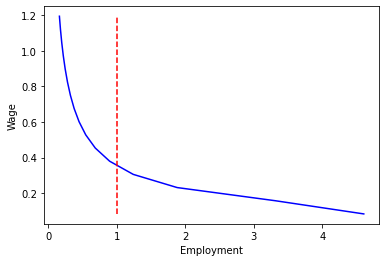

In [17]:
ws = ws[1:]
Ns = Ns[1:]
plt.plot(Ns,ws,'b')
plt.plot(L*np.ones_like(Ns),ws,'r--')
plt.xlabel('Employment')
plt.ylabel('Wage')
plt.show()


Now we find the fixed point.

In [18]:
%%time 

Hss = # set up function

xmax = ws[-1] 
xmin = ws[0]

assert((Hss(xmax) > 0 & 0 >  Hss(xmin) ) | (Hss(xmax) < 0 & 0 <  Hss(xmin)))

w, sol = opt.brentq # use solver to get solution

wss = w
ss0 = ss(param,wss,r,Z)

ss0['w'] = w
ss0['Y'] = Y

D = ss0['D']
n = ss0['n']
my = ss0['my']

print('General Equilibrium Wage = ', round(wss,4))



General Equilibrium Wage =  0.3522
CPU times: user 23.1 s, sys: 111 ms, total: 23.3 s
Wall time: 23.4 s


n(n_) policy small firms


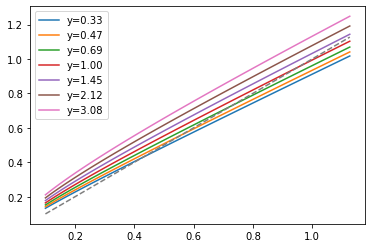

dlog n small firms


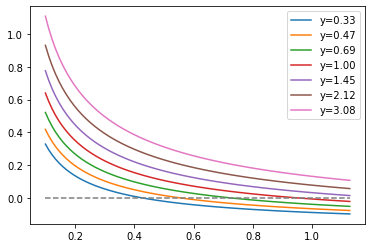

dividends and value for small firms


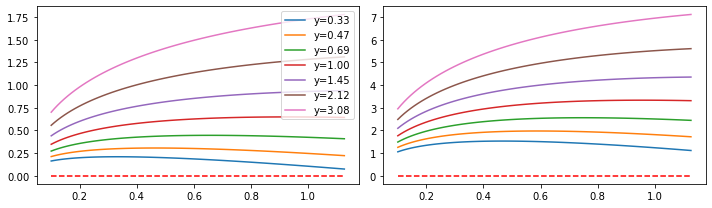

n(n_) policy large firms


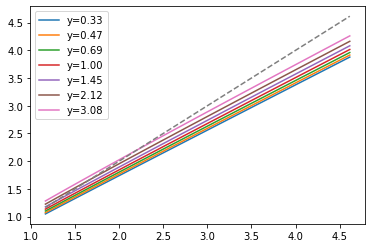

dlog n large firms


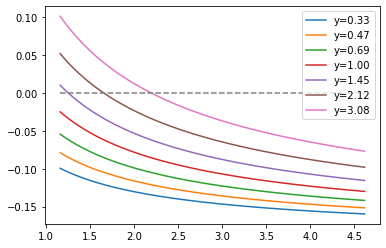

dividends and value for large firms


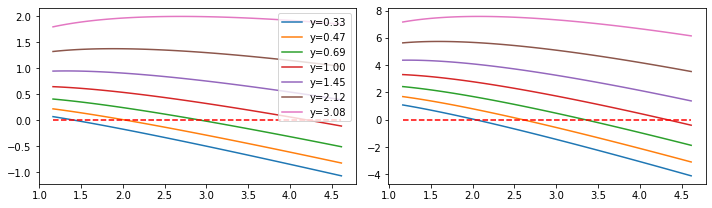

CDF(n) of stationary distribution D with dimensions:  (7, 100)


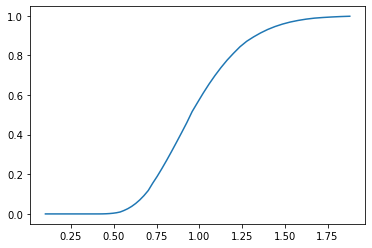

CDF(n;s) of stationary distribution D with dimensions:  (7, 100)


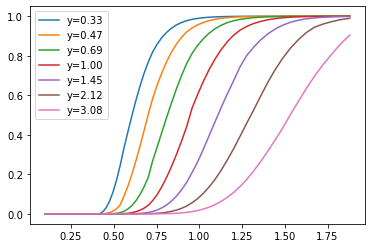

In [19]:
ss_t = ss(param,wss,r,Z)

n = ss_t['n']
D = ss_t['D']
d = ss_t['md']
V = ss_t['mV']

cut = round(nn/2)

start = 0
endit = round((2/3)*nn)

print('n(n_) policy small firms')
for s, y in enumerate(s_grid):
    plt.plot(n_grid[0:cut],n[s,0:cut], label=f'y={y:.2f}')
plt.plot(n_grid[0:cut],n_grid[0:cut],'--')
plt.legend()
plt.show()

print('dlog n small firms')
for s, y in enumerate(s_grid):
    plt.plot(n_grid[0:cut],(n[s,0:cut]/n_grid[0:cut])-1, label=f'y={y:.2f}')
plt.plot(n_grid[0:cut],np.zeros_like(n_grid[0:cut]),'--')
plt.legend()
plt.show()

print('dividends and value for small firms')

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 3))

for s, y in enumerate(s_grid):
    axes[0].plot(n_grid[0:cut],d[s,0:cut], label=f'y={y:.2f}')
axes[0].plot(n_grid[0:cut],np.zeros_like(n_grid[0:cut]),'r--')
#axes[0].title('dividends large firms')
#axes[0].ylabel('Dividends')
    
for s, y in enumerate(s_grid):
    axes[1].plot(n_grid[0:cut],V[s,0:cut], label=f'y={y:.2f}')
axes[1].plot(n_grid[0:cut],np.zeros_like(n_grid[0:cut]),'r--')
#axes[1].title('value large firms')
#axes[1].ylabel('Value Function')
axes[0].legend() #bbox_to_anchor=(0, 0.5),loc='upper left', frameon=False)
fig.tight_layout()

plt.show()

print('n(n_) policy large firms')

for s, y in enumerate(s_grid):
    plt.plot(n_grid[cut:nn],n[s,cut:nn], label=f'y={y:.2f}')
plt.plot(n_grid[cut:nn],n_grid[cut:nn],'--')
plt.legend()
plt.show()

print('dlog n large firms')

for s, y in enumerate(s_grid):
    plt.plot(n_grid[cut:nn],(n[s,cut:nn]/n_grid[cut:nn])-1, label=f'y={y:.2f}')
plt.plot(n_grid[cut:nn],np.zeros_like(n_grid[cut:nn]),'--')
plt.legend()
plt.show()

print('dividends and value for large firms')

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 3))

for s, y in enumerate(s_grid):
    axes[0].plot(n_grid[cut:nn],d[s,cut:nn], label=f'y={y:.2f}')
axes[0].plot(n_grid[cut:nn],np.zeros_like(n_grid[cut:nn]),'r--')
#axes[0].title('dividends large firms')
#axes[0].ylabel('Dividends')
    
for s, y in enumerate(s_grid):
    axes[1].plot(n_grid[cut:nn],V[s,cut:nn], label=f'y={y:.2f}')
axes[1].plot(n_grid[cut:nn],np.zeros_like(n_grid[cut:nn]),'r--')
#axes[1].title('value large firms')
#axes[1].ylabel('Value Function')
axes[0].legend() #bbox_to_anchor=(0, 0.5),loc='upper left', frameon=False)
fig.tight_layout()

plt.show()

print('CDF(n) of stationary distribution D with dimensions: ', D.shape )
plt.plot(n_grid[start:endit], D.sum(axis=0).cumsum()[start:endit])
plt.show()

print('CDF(n;s) of stationary distribution D with dimensions: ', D.shape )

for s, y in enumerate(s_grid):
    plt.plot(n_grid[start:endit], D[s,start:endit].cumsum()/s_dist[s], label=f'y={y:.2f}')
plt.legend()
plt.show()


In [241]:
print(ss_t['Nd'])
print(ss_t['Y'])

1.0000000000000002
1.059617049897919


**Calibrating with Multiple Moments**

A trick is to calibrate one parameter at a time, and use the previous equilibrium as a guess.

But we are not just calibrating $w$ to solve for labor market clearing with $L=1$, we also need to make sure that in the initial steady state, we calibrate $Y = 1$, which does not happen with the calibration above. To do this, one way is to target two equations, with two variables (w,Z)

$$ Y = \int y(w,Z) D(w,Z) = 1$$ 
$$ L = \int n_{-} D(w,Z) = 1$$ 

Unlike with Huggett, now your target is a *system* of nonlinear residual equations that need to be cleared in equilibrium, i.e. we need to find the root or fixed point of this system (when it crosses the origin).

$$ \begin{array}{l}
H_{LMC}=\mathcal{N}_t(w, Z)-1=0 \\
H_{GMC}=\mathcal{Y}_{t}(w, Z)-1=0
\end{array}$$

In the final solution you should probably also make sure to add an extra equilibrium condition to make sure we are OK. Take asset market clearing 

$$ C = r A + w N  = \Phi + w N $$

and make sure that also 

$$  C = Y - \Psi $$ 

$$ H_{AMC+GMC}= 1 - \Psi  - \Phi -  w N = 0$$ 



In [22]:
%%time 

# residual function
def GEresid(x):
    w0, Z0 = x
    if w0 < 0  or Z0 <= 0 :
        raise ValueError('Clearly invalid inputs')
            
    H = ss(param,w0,r,Z0)
        
    return # ARRAY WITH VECTOR OF RESIDUAL FUNCTIONS TO SOLVE

w_guess , Z_guess = wss, Z

# USE THE FOLLOWING

(w, Z), _ = utilities.broyden_solver(GEresid, np.array([w_guess, Z_guess]), noisy=True)



On iteration 0
x = 0.352,1.000
y = 0.000,0.060


On iteration 1
x = 0.332,0.944
y = 0.000,0.000


On iteration 2
x = 0.332,0.944
y = -0.000,0.000


On iteration 3
x = 0.332,0.944
y = 0.000,-0.000


On iteration 4
x = 0.332,0.944
y = -0.000,-0.000


CPU times: user 11.2 s, sys: 73.7 ms, total: 11.3 s
Wall time: 11.4 s


In [23]:
ssGE = ss(param,w,r,Z)

print('w, Z = ', round(w,3) ,round(Z,3))
print('L, Y --> ', round(ssGE['Nd'],4) ,round(ssGE['Y'],4) , )

print('')

print('dw', w - w_guess)
print('dZ', Z - Z_guess)

# Note output was too high, so we will have to cut Z. Doing so reduces labor demand, and hence, w needs to fall

w, Z =  0.332 0.944
L, Y -->  1.0 1.0

dw -0.019807844670151786
dZ -0.05606063667632366


### Adding Exogenous Entry and Exit 

To allow for exogenous exit and entry, we need to modify our code. I assume all entrants are injected at the bottom of the employment distribution, i.e. $G(s,n_{0})$, independently of $s$. However, the first $s$ draw is taken from the stationary distribution of the Markov process. 

An alternative would be to assume that the initial draw comes from something else, like a Pareto distribution, or that different firms are injected into different portions of the distribution of firms.

Similarly to what you saw in problem set 1 question 1, the possibility of death acts like extra discounting

$$ ... \frac{1 - \delta}{1+r_{t}}\mathbb{E}_{s'}\left[V_{t+1}(s',n)\big\vert s\right]$$

Now with exit and entry, we have to modify the law of motion of the distribution. 

$$ D_{t}\left(s',n\right)=\sum_{s,n}\left(1-\delta\right)\Pi_{s,s'}\pi\left(n_{t}^{*}\left(s,n_{-}\right)\in N_{\epsilon}\left(n\right)\right)D_{t-1}\left(s,n_{-}\right)+m_{t}G\left(s',n\right) $$

Thus, now the mass of firms will likely not be $1$.

$$ N=\left(1-\delta\right)N+m\implies N=\frac{m}{\delta} $$


In [24]:
# Thus far, we have produced a mass-1 stationary distribution
np.sum(np.sum(D))

1.0000000000000233

In [25]:
_, mGs = np.meshgrid(n_grid,s_dist) 

# MAKE SURE TO GET APPROPRIATE G

param['G'] = G # add to parameter space 


In [26]:
# We modify exit in the incumbent problem, and add entry and exit to the distribution

def firm(Vn_p,V_p,param,w,r,Z):
    
    
    
    return Vn, V, n, d, yy, Psi

param['firm'] = firm

def forward(D, m, G, δ, Π_T, x_i, x_pi):
    

# Create function D = forward_ss(param,r,Y)
def forward_ss(param, x_i, x_pi, m):
    

# Create a function that generates SS aggregates given different endogenous GE objects  

def ss(param,w,r,Z,m): 

    return {'Nd': Nd, 'Y': Y, 'V': V, 'd': d, 'Psi': Psi, 'D': D, 'n': n, 'my': my, 'md': md, 'mPsi': mPsi , 'Vn': Vn, 'mV': mV, 'Ve': Ve}
    

In [27]:
m = δ # guarantees that N = 1 in the SS

ssGE = ss(param,w,r,Z,m)


In [28]:
# We are guaranteed to stay within 1 since m = δ

np.sum(np.sum(ssGE['D']))

1.000000000000002

In [29]:
m = δ*1.2 # higher entry rate

ssGE = ss(param,w,r,Z,m)



In [30]:
print(round(np.sum(np.sum(ssGE['D'])),5))
print(m/δ)

1.2
1.2


Solve the model again, but now modified to include entry and exit.

In [31]:
%%time 

# residual function
def GEresid(x):
    #

w_guess , Z_guess = w, Z # Careful with this step

(w, Z), _ = utilities.broyden_solver# 



On iteration 0
x = 0.332,0.944
y = -0.444,-0.113


backtracking

On iteration 1
x = 0.159,0.901
y = -0.071,-0.031


On iteration 2
x = 0.129,0.907
y = 0.069,0.011


On iteration 3
x = 0.145,0.913
y = -0.000,0.001


On iteration 4
x = 0.145,0.912
y = -0.000,-0.000


On iteration 5
x = 0.145,0.912
y = 0.000,0.000


On iteration 6
x = 0.145,0.912
y = 0.000,0.000


On iteration 7
x = 0.145,0.912
y = -0.000,-0.000


CPU times: user 17.1 s, sys: 111 ms, total: 17.2 s
Wall time: 17.4 s


In [32]:
# Note that this will likely not satisfy free entry 
H = ss(param,w,r,Z,m)



In [33]:
# A lower value of investment induced by exit shocks depresses labor demand, and hence, wages. 
print(w - w_guess)
print(Z - Z_guess)

-0.18728870324037408
-0.03215529866701605


### Endogenizing Entry

Now we make sure that free entry also holds, or that 

$$ V^{e}-w\kappa^{e}=\frac{1}{1+r}\int V\left(s,n_{0}\right)G\left(s,n_{0}\right)-w\kappa^{e}\rightarrow 0 \iff m > 0 $$ 

and that since entry costs are paid in labor, labor markets clear.

$$ N_{t}^{f} + m_{t}\kappa^{e}\le L_{t} $$ 



In [34]:
%%time 

# residual function
def GEresid(x):
    w0, Z0, m0 = x
    if w0 < 0  or Z0 <= 0:
        raise ValueError('Clearly invalid inputs')
            
    H = ss(param,w0,r,Z0,m0)
        
    return np.array(#)

w_guess , Z_guess, m_guess = w, Z, δ

(w, Z, m), _ = utilities.broyden_solver#



On iteration 0
x = 0.145,0.912,0.100
y = -0.067,-0.167,1.222


backtracking

On iteration 1
x = 0.216,0.415,0.192
y = -0.316,-0.479,0.462


On iteration 2
x = 0.364,0.137,0.337
y = -0.325,-0.775,-0.244


On iteration 3
x = 0.509,0.308,0.395
y = -0.183,-0.393,-0.115


On iteration 4
x = 0.642,0.464,0.454
y = -0.003,0.096,0.000


On iteration 5
x = 0.589,0.430,0.433
y = -0.048,-0.031,0.008


On iteration 6
x = 0.587,0.426,0.438
y = -0.038,-0.030,0.002


On iteration 7
x = 0.586,0.425,0.447
y = -0.020,-0.013,0.002


On iteration 8
x = 0.582,0.421,0.460
y = 0.009,0.006,-0.001


On iteration 9
x = 0.583,0.422,0.456
y = 0.000,0.000,-0.000


On iteration 10
x = 0.583,0.422,0.456
y = 0.000,0.000,-0.000


On iteration 11
x = 0.583,0.422,0.456
y = 0.000,0.000,-0.000


On iteration 12
x = 0.583,0.422,0.456
y = -0.000,-0.000,0.000


On iteration 13
x = 0.583,0.422,0.456
y = -0.000,-0.000,0.000


On iteration 14
x = 0.583,0.422,0.456
y = -0.000,-0.000,0.000


CPU times: user 31.5 s, sys: 192 ms, to

In [35]:

print(w - w_guess, Z - Z_guess, m - m_guess)


0.438257008555218 -0.48989992477916205 0.35625259772254014


In [36]:
H = ss(param,w,r,Z,m)


In [37]:
# Mass of firms

print(m/δ)

4.562525977225401


In [38]:
%%time

# Take as given Z, start the economy at above Y = 1, L = 1, and (w,m)
# Reduce L by 10%, clear labor markets and free entry (w,m) and look at what happens with output
L_shock = L*(1-0.1)

# residual function
def GEresid(x):
    w0, m0 = x
    if w0 < 0:
        raise ValueError('Clearly invalid inputs')
            
    H = ss(param,w0,r,Z,m0)
        
    return np.array(#)

w_guess , m_guess = w, m

(w, m), _ = utilities.broyden_solver#




On iteration 0
x = 0.583,0.456
y = 0.100,0.000


On iteration 1
x = 0.583,0.411
y = 0.000,0.000


CPU times: user 7.33 s, sys: 41.9 ms, total: 7.38 s
Wall time: 7.44 s


In [39]:
print('When L falls by 10%, dw % = ', round(100*(w - w_guess)/w_guess,2), ' dm = ', round(100*(m - m_guess)/m_guess,2))

# This barely moves w, since a decline in L increases w and decreases incumbent labor demand and profit
# The fall in profits due to rising costs decreases entry, and thus, shifts labor demand left
# Wages barely fall, but entry decreases.


When L falls by 10%, dw % =  0.0  dm =  -10.0


Now consider the economy experiences a fall in TFP. Then, we shock $Z$ and observe what happens to entry and the wage.

On iteration 0
x = 0.691,0.454
y = -0.037,-0.095


On iteration 1
x = 0.622,0.458
y = 0.005,-0.000


On iteration 2
x = 0.622,0.455
y = -0.000,-0.000


On iteration 3
x = 0.622,0.455
y = 0.000,-0.000


On iteration 4
x = 0.622,0.455
y = 0.000,-0.000


On iteration 5
x = 0.622,0.455
y = 0.000,-0.000


When Z falls by 10%, dw % =  -9.98  dm =  0.3  Y/L =  -0.1174453636825814
CPU times: user 15.4 s, sys: 67.2 ms, total: 15.5 s
Wall time: 15.5 s


You should observe that $w$ does not change while $m$ falls. 

## Stochastic Simulation

Now you will draw a random sample of $B$ firms and track their life cycle over $T$ periods, allowing them to exit and receive productivity shocks in every period.


In [158]:
# Initialize the average firm in the economy

sss = np.sum(G[0:ns,0]*s_grid.T)

s_grid

# step 1: find the i such that a' lies between gridpoints a_i and a_(i+1)
s_i = np.searchsorted(s_grid, sss) - 1
    
# step 2: implement (1) to obtain lottery probabilities pi
s0  = s_grid[s_i]

print('Average firm has ( s0 , n0 ) = (' , s0, ',' , n_grid[4], ')')

# We want to track a history of firms over time: s,n_ -> s', n(s,n_)
# Note that conditional on s, a row of Π, we know probabilities of going to each s' 


Average firm has ( s0 , n0 ) = ( 1.0 , 0.14584164060383026 )


In [41]:
from scipy.stats import multinomial

In [209]:
# result of flipping a coin loading δ, T times, tested B times.

T = 50
B = 5000

#

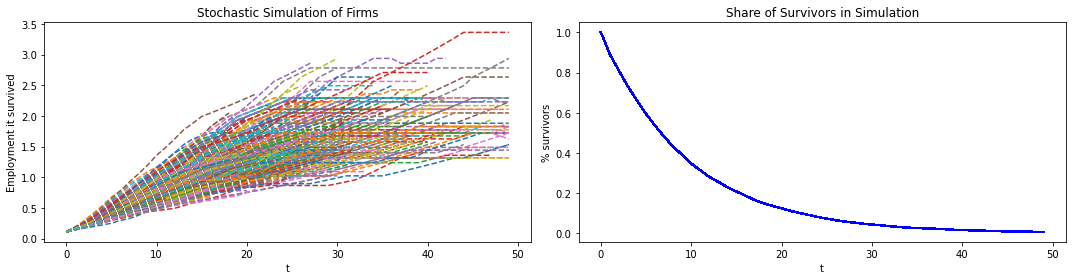

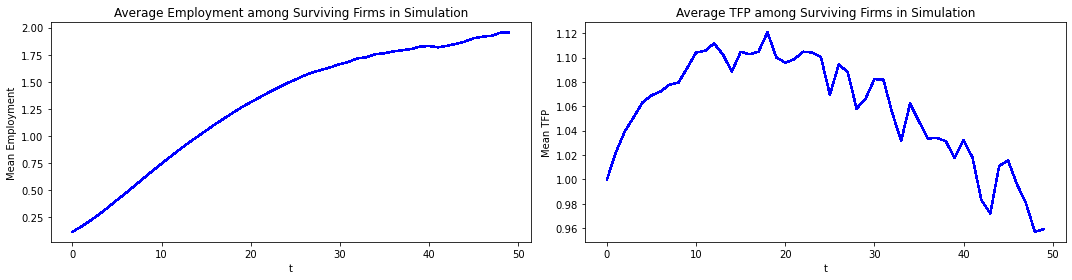

In [214]:
for b in range(0,B):
    for t in range(1,T): 
        time[t,b] = t
        # KEEP ALIVE
        # Problem n' not on the grid -> get it                
        π       =                          # π(s,s') prob of each draw cond on s
        x       =  # index where s' drawn falls
        s_t[t,b]  =                                   # let s = s' and update path
        n__t[t,b] =               # let n_ = n(s,n_) and update path


Th = T 



valive = np.sum(alive,axis = 1)

mn__t = np.sum(n__t*alive, axis=1)/valive
ms_t = np.sum(s_t*alive, axis=1)/valive


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))

for b in range(0,B):
    npath = [float('nan') if x==0 else x for x in n__t[0:Th,b]*alive[0:Th,b]]
    axes[0].plot(time[0:Th,b],npath,'--')
axes[0].set_title('Stochastic Simulation of Firms')
axes[0].set_xlabel('t')
axes[0].set_ylabel('Employment it survived')

axes[1].plot(time,valive/B,'b')
axes[1].set_title('Share of Survivors in Simulation')
axes[1].set_xlabel('t')
axes[1].set_ylabel('% survivors')
fig.tight_layout()
plt.show()


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))

axes[0].plot(time,mn__t,'b')
axes[0].set_title('Average Employment among Surviving Firms in Simulation')
axes[0].set_xlabel('t')
axes[0].set_ylabel('Mean Employment')

axes[1].plot(time,ms_t,'b')
axes[1].set_title('Average TFP among Surviving Firms in Simulation')
axes[1].set_xlabel('t')
axes[1].set_ylabel('Mean TFP')
fig.tight_layout()

plt.show()


### Hopenhayn Rogerson's Trick: Homogeneity of Degree 1 in Entry

A clever way to solve this problem is to realize that the model is homogenous of degree 1 in the entry mass $m$. You should check out the original paper for this algorithm, although in my opinion it only works in particular simpler versions of the model.



# Appendix:  Notes on Wage Phillips Curve  Derivations in One Asset HANK

**As an exercise, derive the full forward looking wage Phillips Curve yourself, not ignoring the last term in the FOC as I do here for exposition.**

Recall our problem
$$ \begin{array}{rl}
\max_{c_{it}} & \mathbb{E}_{0}\sum_{t=0}^{\infty}\beta^{t}\left(u\left(c_{it}\right)-v\left(n_{it}\right)\right)\\
 & c_{it}+a_{it}\leq\left(1+r_{t-1}\right)a_{it-1}+z_{it}\\
 & a_{it}\geq\underline{a}
\end{array} $$

Post tax income depends on pre-tax income

$$ z_{it}=\tau_{t}y_{it}^{1-\lambda}\leftarrow y_{it}=\frac{W_{t}}{P_{t}}s_{it}n_{it}=w_{t}s_{it}n_{it} $$

$n$ is taken as given by households, chosen along with $w$ by unions, who maximize: 

$$ \sum_{t\ge0}\beta^{t}\left(\int\left\{ u\left(c_{it}\right)-v\left(n_{it}\right)\right\} dD_{it}-\frac{\psi}{2}\left(\frac{W_{k,t}}{W_{k,t-1}}-1\right)^{2}\right) $$

I recommend you start with a simpler setting where unions take as a reference wage the *aggregate* index (I call it macro pricing as opposed to micro pricing), or ignore the effects that their wage setting today will have on their price tomorrow. This will deliver a Phillips Curve with $0$ coefficient on future inflation, but will help you learn the algebra steps.

$$ \sum_{t\ge0}\beta^{t}\left(\int\left\{ u\left(c_{it}\right)-v\left(n_{it}\right)\right\} dD_{it}-\frac{\psi}{2}\left(\frac{W_{k,t}}{W_{k,t-1}}-1\right)^{2}\right) $$

Unions take as given expenditure aggregation  of all households across all unions

$$ W_{t}n_{it}=\int_{0}^{1}W_{kt}\left(\frac{W_{kt}}{W_{t}}\right)^{-\epsilon}N_{t}dk$$ 

and the homogenous hours supplied by all households

$$ n_{it}\equiv\int_{0}^{1}n_{ikt}dk=\int_{0}^{1}\left(\frac{W_{kt}}{W_{t}}\right)^{-\epsilon}N_{t}dk$$ 

where recall

$$ c_{it}\leq\left(1+r_{t-1}\right)a_{it-1}-a_{it}+z_{it}\\z_{it}=\tau_{t}y_{it}^{1-\lambda}\\y_{it}=\frac{W_{t}}{P_{t}}s_{it}n_{it} $$


Note that 

$$ c_{it}+a_{it}=z_{it}\left(\{W_{kt}\}_{k}\right)+(1+r)a_{it-1}+... $$ 

So holding a_{it} constant, we know that, c is linear in z

$$ \frac{\partial c_{it}}{\partial W_{kt}}=\frac{\partial c_{it}}{\partial z_{it}}\frac{\partial z_{it}}{\partial W_{kt}}=\frac{\partial z_{it}}{\partial W_{kt}}$$ 


$$ z_{it}	=\tau_{t}\left(\frac{1}{P_{t}}s_{it}W_{t}n_{it}\right)^{1-\lambda}=\tau_{t}\left(\frac{1}{P_{t}}s_{it}\int_{0}^{1}W_{kt}n_{ikt}dk\right)^{1-\lambda} $$ 

$$ \frac{\partial c_{it}}{\partial W_{kt}}=\frac{\partial z_{it}}{\partial W_{kt}}=\left(1-\epsilon\right)\left(1-\lambda\right)\frac{z_{it}}{y_{it}}\frac{1}{P_{t}}s_{it}\left(\frac{W_{kt}}{W_{t}}\right)^{-\epsilon}N_{t}=\left(1-\epsilon\right)\left(1-\lambda\right)\frac{z_{it}}{y_{it}}\frac{1}{P_{t}}s_{it}n_{ikt} $$ 

$$ \frac{\partial n_{it}}{\partial W_{kt}}=-\epsilon\left(\frac{W_{kt}}{W_{t}}\right)^{-\epsilon-1}\frac{1}{W_{t}}N_{t}dk=-\epsilon\left(\frac{W_{kt}}{W_{t}}\right)^{-\epsilon}\frac{1}{W_{kt}}N_{t} $$ 

The the first order condition ignoring the effect on future prices

$$ \int\left\{ u'\left(c_{it}\right)\frac{\partial c_{it}}{\partial W_{kt}}-v'\left(n_{it}\right)\frac{\partial n_{it}}{\partial W_{kt}}\right\} dD_{it}-\psi\pi_{t}^{W}\frac{1}{W_{t-1}} = 0 $$ 

$$ \int\left\{ u'\left(c_{it}\right)\left(1-\epsilon\right)\left(1-\lambda\right)\frac{z_{it}}{y_{it}}\frac{1}{P_{t}}s_{it}n_{ikt}+v'\left(n_{it}\right)\epsilon\left(\frac{W_{kt}}{W_{t}}\right)^{-\epsilon}\frac{1}{W_{kt}}N_{t}\right\} dD_{it}-\psi\pi_{t}^{W}\frac{1}{W_{t-1}} = 0$$ 

$$ \int\left\{ v'\left(n_{it}\right)\epsilon\left(\frac{W_{kt}}{W_{t}}\right)^{-\epsilon}\frac{1}{W_{kt}}N_{t}-u'\left(c_{it}\right)\left(\epsilon-1\right)\frac{\partial z_{it}}{\partial y_{it}}\frac{1}{P_{t}}s_{it}n_{ikt}\right\} dD_{it}-\psi\pi_{t}^{W}\frac{1}{W_{t-1}} = 0 $$ 

$$ \int\left\{ v'\left(n_{it}\right)\epsilon\left(\frac{W_{kt}}{W_{t}}\right)^{-\epsilon}N_{t}-u'\left(c_{it}\right)\left(\epsilon-1\right)\frac{\partial z_{it}}{\partial y_{it}}\frac{W_{kt}}{P_{t}}s_{it}n_{ikt}\right\} dD_{it}-\psi\pi_{t}^{W}\frac{W_{kt}}{W_{t-1}}=0 $$ 

Letting $W_{kt}=W_{t} and n_{kt}=n_{ikt}=N_{t}$

$$ \int\left\{ v'\left(N_{t}\right)\epsilon N_{t}-u'\left(c_{it}\right)\left(\epsilon-1\right)\frac{\partial z_{it}}{\partial y_{it}}\frac{W_{t}}{P_{t}}s_{it}N_{t}\right\} dD_{it}-\psi\pi_{t}^{W}\frac{W_{t}}{W_{t-1}}=0$$ 

$$ \pi_{t}^{W}\left(1+\pi_{t}^{W}\right)=\frac{\epsilon}{\psi}\int N_{t}\left\{ v'\left(N_{t}\right)-\left(\frac{\epsilon-1}{\epsilon}\right)\frac{\partial z_{it}}{\partial y_{it}}\frac{W_{t}}{P_{t}}s_{it}u'\left(c_{it}\right)\right\} dD_{it} $$ 

Where note that since $y_{it}=\frac{W_{t}}{P_{t}}s_{it}n_{it}$ , we can re-write in terms of how changes in employment affect post-tax income. 

$$ \frac{\partial z_{it}}{\partial n_{it}}=\frac{\partial z_{it}}{\partial y_{it}}\frac{W_{t}}{P_{t}}s_{it} $$ 

$$ \pi_{t}^{W}\left(1+\pi_{t}^{W}\right)=\frac{\epsilon}{\psi}\int N_{t}\left\{ v'\left(N_{t}\right)-\left(\frac{\epsilon-1}{\epsilon}\right)\frac{\partial z_{it}}{\partial n_{it}}u'\left(c_{it}\right)\right\} dD_{it} $$ 

Define an appropriate aggregator

$$ \pi_{t}^{W}\left(1+\pi_{t}^{W}\right)=\frac{\epsilon}{\psi}N_{t}^{1+\varphi}\left\{ 1-\frac{1}{\left(\frac{\epsilon-1}{\epsilon}\right)^{-1}N_{t}^{\varphi}\tilde{C}_{t}^{\sigma}}\frac{W_{t}}{P_{t}}\right\} \iff\frac{W_{t}}{P_{t}}=\mu_{t}\left(\frac{\epsilon-1}{\epsilon}\right)^{-1}N_{t}^{\varphi}\tilde{C}_{t}^{\sigma}$$ 

$$ \mu_{t}=1-\frac{\pi_{t}^{W}\left(1+\pi_{t}^{W}\right)}{\frac{\epsilon}{\psi}N_{t}^{1+\varphi}},\quad\tilde{C}_{t}=\left(\int s_{it}\left(c_{it}\left(s,a_{-}\right)\right)^{-\sigma}dD_{it}\left(s,a_{-}\right)\right)^{-\frac{1}{\sigma}} $$

RA-RBC is a good benchmark to check to see if you messed up the algebra is to set $\pi=0, \lambda=0, s_{it}=1$. 

$$ \frac{W_{t}}{P_{t}}=\left(\frac{\epsilon-1}{\epsilon}\right)^{-1}\frac{v'\left(N_{t}\right)}{u'\left(C_{t}\right)}=\left(\frac{\epsilon-1}{\epsilon}\right)^{-1}C_{t}^{\sigma}N_{t}^{\varphi}$$ 

where there's fixed labor wedge. In RANK Rotemberg there's a time varying labor wedge.

$$ \pi_{t}^{W}\left(1+\pi_{t}^{W}\right)=\frac{\epsilon}{\psi}N_{t}^{1+\varphi}\left\{ 1-\frac{\frac{W_{t}}{P_{t}}}{\left(\frac{\epsilon-1}{\epsilon}\right)^{-1}N_{t}^{\varphi}C_{t}^{\sigma}}\right\} \implies\frac{W_{t}}{P_{t}}=\mu_{t}\left(\frac{\epsilon-1}{\epsilon}\right)^{-1}N_{t}^{\varphi}C_{t}^{\sigma}$$ 

$$ \mu_{t}=1-\frac{\pi_{t}^{W}\left(1+\pi_{t}^{W}\right)}{\frac{\epsilon}{\psi}N_{t}^{1+\varphi}}$$

As an exercise, derive the full forward looking wage Phillips Curve yourself, not ignoring the last term in the FOC as I did here for exposition.